In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
df_train = pd.read_csv('../data/train.csv')

C:\Users\yizhe\AppData\Local\Temp\ipykernel_15668\788172147.py:1: DtypeWarning: Columns (41) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv('../data/train.csv')


In [23]:
df_train.head()

,id,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,...,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,88471,2016-05,KALLANG/WHAMPOA,4 ROOM,3B,UPP BOON KENG RD,10 TO 12,90.0,Model A,2006,...,78,1,1.317659,103.882504,1138.633422,Geylang Methodist School,224,0,1.317659,103.882504
1,122598,2012-07,BISHAN,5 ROOM,153,BISHAN ST 13,07 TO 09,130.0,Improved,1987,...,45,1,1.349783,103.854529,447.894399,Kuo Chuan Presbyterian Secondary School,232,0,1.350110,103.854892
2,170897,2013-07,BUKIT BATOK,EXECUTIVE,289B,BT BATOK ST 25,13 TO 15,144.0,Apartment,1997,...,39,0,1.345245,103.756265,180.074558,Yusof Ishak Secondary School,188,0,1.342334,103.760013
3,86070,2012-04,BISHAN,4 ROOM,232,BISHAN ST 22,01 TO 05,103.0,Model A,1992,...,20,1,1.354789,103.844934,389.515528,Catholic High School,253,1,1.354789,103.844934
4,153632,2017-12,YISHUN,4 ROOM,876,YISHUN ST 81,01 TO 03,83.0,Simplified,1987,...,74,0,1.416280,103.838798,312.025435,Orchid Park Secondary School,208,0,1.414888,103.838335


In [24]:
df_train.dtypes.value_counts()

int64      32
float64    25
object     20
Name: count, dtype: int64

In [25]:
df_train.drop(columns=["id"], inplace=True) # drop id column since it is not useful for modeling
num_features = df_train.select_dtypes(include=[np.number]).columns
cat_features = df_train.select_dtypes(include=['object', 'category']).columns

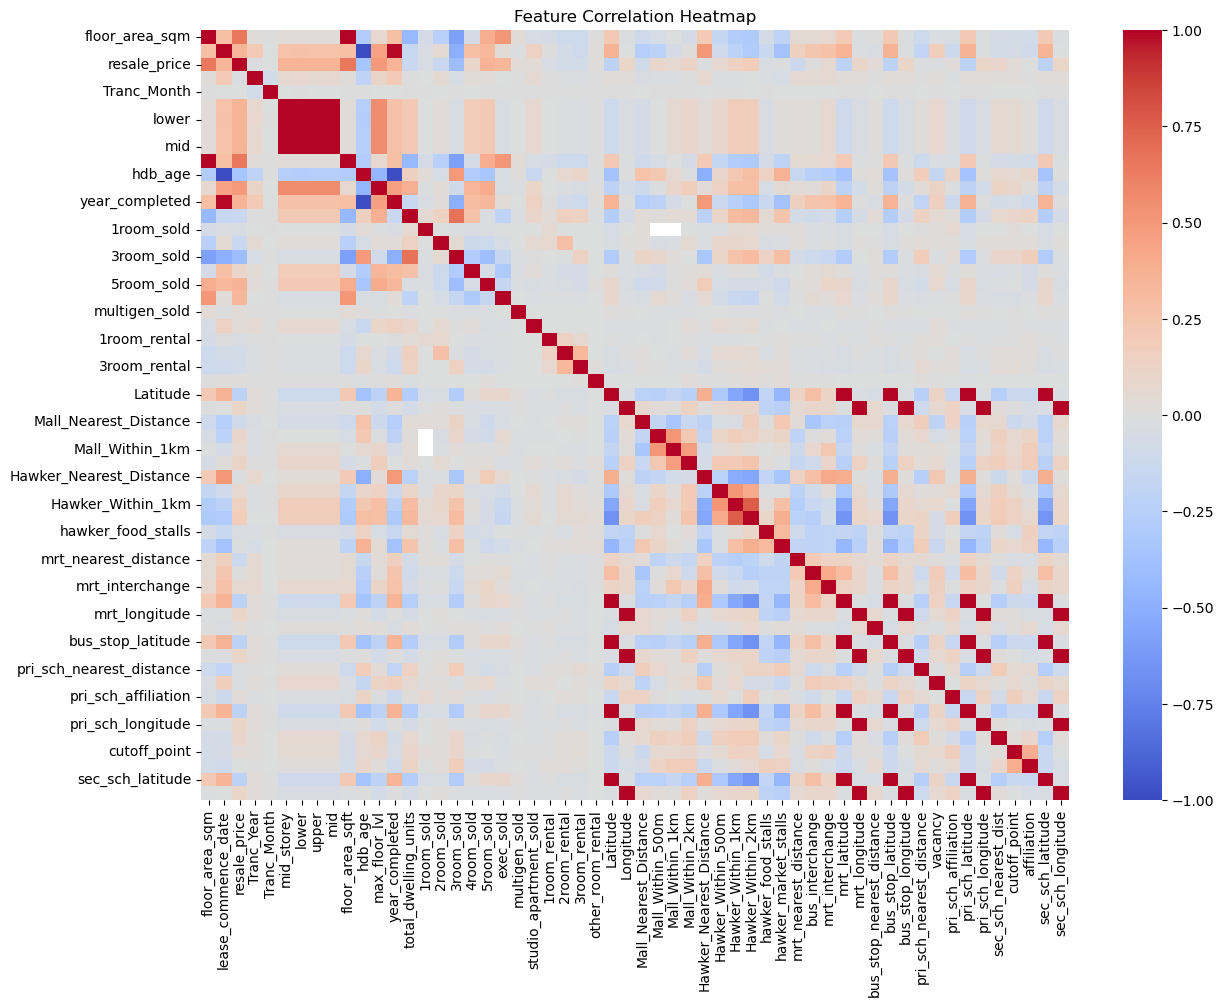

In [26]:
corr = df_train[num_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [27]:
corr = df_train[num_features].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = upper.stack().sort_values(ascending=False)
high_corr_pairs.head(20)

lease_commence_date  hdb_age               1.000000
mid_storey           mid                   1.000000
floor_area_sqm       floor_area_sqft       1.000000
Longitude            bus_stop_longitude    0.999937
Latitude             bus_stop_latitude     0.999819
lower                mid                   0.999423
mid_storey           lower                 0.999423
                     upper                 0.999421
upper                mid                   0.999421
Longitude            pri_sch_longitude     0.999227
bus_stop_longitude   pri_sch_longitude     0.999172
Longitude            sec_sch_longitude     0.998698
bus_stop_longitude   sec_sch_longitude     0.998644
pri_sch_longitude    sec_sch_longitude     0.998426
lower                upper                 0.997688
Latitude             pri_sch_latitude      0.997589
bus_stop_latitude    pri_sch_latitude      0.997443
Longitude            mrt_longitude         0.996590
mrt_longitude        bus_stop_longitude    0.996571
            

In [28]:
check_duplicate_attributes = [
    ("lease_commence_date", "hdb_age"),
    ("mid_storey", "mid"),
    ("floor_area_sqm", "floor_area_sqft")
]

for i, j in check_duplicate_attributes:
    same = np.isclose(df_train[i], df_train[j], equal_nan=True).all()
    print(f"{i} vs {j}: {same}")

lease_commence_date vs hdb_age: False
mid_storey vs mid: True
floor_area_sqm vs floor_area_sqft: False


In [29]:
#drop the duplicate attributes
df_train = df_train.drop(columns=['mid_storey', 'floor_area_sqft', 'lease_commence_date'])

num_features = df_train.select_dtypes(include=[np.number]).columns
cat_features = df_train.select_dtypes(include=['object', 'category']).columns

corr = df_train[num_features].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = upper.stack().sort_values(ascending=False)

Clean num_col first:

1. Check negative values
2. check logic violations

In [30]:
df_train[num_features].isnull().sum().sort_values(ascending=False)

Hawker_Within_500m           97390
Mall_Within_500m             92789
Hawker_Within_1km            60868
Hawker_Within_2km            29202
Mall_Within_1km              25426
Mall_Within_2km               1940
Mall_Nearest_Distance          829
pri_sch_longitude                0
bus_interchange                  0
Hawker_Nearest_Distance          0
sec_sch_latitude                 0
affiliation                      0
cutoff_point                     0
hawker_food_stalls               0
hawker_market_stalls             0
mrt_nearest_distance             0
mrt_interchange                  0
pri_sch_latitude                 0
mrt_latitude                     0
mrt_longitude                    0
sec_sch_nearest_dist             0
bus_stop_latitude                0
bus_stop_longitude               0
pri_sch_nearest_distance         0
vacancy                          0
pri_sch_affiliation              0
bus_stop_nearest_distance        0
floor_area_sqm                   0
resale_price        

In [31]:
df_train[num_features].head()

,floor_area_sqm,resale_price,Tranc_Year,Tranc_Month,lower,upper,mid,hdb_age,max_floor_lvl,year_completed,...,pri_sch_nearest_distance,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,90.0,680000.0,2016,5,10,12,11,15,25,2005,...,1138.633422,78,1,1.317659,103.882504,1138.633422,224,0,1.317659,103.882504
1,130.0,665000.0,2012,7,7,9,8,34,9,1987,...,415.607357,45,1,1.349783,103.854529,447.894399,232,0,1.350110,103.854892
2,144.0,838000.0,2013,7,13,15,14,24,16,1996,...,498.849039,39,0,1.345245,103.756265,180.074558,188,0,1.342334,103.760013
3,103.0,550000.0,2012,4,1,5,3,29,11,1990,...,389.515528,20,1,1.354789,103.844934,389.515528,253,1,1.354789,103.844934
4,83.0,298000.0,2017,12,1,3,2,34,4,1987,...,401.200584,74,0,1.416280,103.838798,312.025435,208,0,1.414888,103.838335


In [32]:
(df_train[num_features] < 0).sum().sort_values(ascending=False) # check for negative values in numeric columns

floor_area_sqm               0
Mall_Within_1km              0
Hawker_Nearest_Distance      0
Hawker_Within_500m           0
Hawker_Within_1km            0
Hawker_Within_2km            0
hawker_food_stalls           0
hawker_market_stalls         0
mrt_nearest_distance         0
bus_interchange              0
mrt_interchange              0
mrt_latitude                 0
mrt_longitude                0
bus_stop_nearest_distance    0
bus_stop_latitude            0
bus_stop_longitude           0
pri_sch_nearest_distance     0
vacancy                      0
pri_sch_affiliation          0
pri_sch_latitude             0
pri_sch_longitude            0
sec_sch_nearest_dist         0
cutoff_point                 0
affiliation                  0
sec_sch_latitude             0
Mall_Within_2km              0
Mall_Within_500m             0
resale_price                 0
Mall_Nearest_Distance        0
Tranc_Year                   0
Tranc_Month                  0
lower                        0
upper   

No negative values

Identify bool from generic attributes

In [33]:
bool_like_cols = [
    col for col in num_features
    if df_train[col].dropna().isin([0, 1]).all()
]

bool_like_cols

['bus_interchange', 'mrt_interchange', 'pri_sch_affiliation', 'affiliation']

Clean float col

In [34]:
bool_like_float_cols = [
    col for col in num_features
    if df_train[col].isin((0.0, 1.0)).all()
]

bool_like_float_cols

['bus_interchange', 'mrt_interchange', 'pri_sch_affiliation', 'affiliation']

In [35]:
print(df_train["Mall_Within_500m"])

0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
         ... 
150629    NaN
150630    1.0
150631    NaN
150632    NaN
150633    1.0
Name: Mall_Within_500m, Length: 150634, dtype: float64


Feature eng within num col only:

time: 
tranc_month_year -> 'Tranc_Year'+ 'Tranc_Month'
compare for idk.... inflation??

Apartment further details:


resale data:
popular hdb sold->  '1room_sold' + '2room_sold' + '3room_sold' + 
       '4room_sold' + '5room_sold' + 'exec_sold' + 'multigen_sold' +
       'studio_apartment_sold'
       
popular rental spot -> '1room_rental' + '2room_rental' + '3room_rental' +
       'other_room_rental'

school prestige:
'vacancy', 'pri_sch_affiliation',
       'cutoff_point', 'affiliation'

popular primary school -> 1/vacancy

secondary_school_prestige -> cutoff_point 




TODO: fill missing relavent values using high corr 0.9x

In [36]:
threshold = 0.8

for (col1, col2), corr_val in high_corr_pairs.items():
    
    # 1. filter low correlation
    if corr_val < threshold:
        continue

    # 2. ensure columns exist (important after drops)
    if col1 not in df_train.columns or col2 not in df_train.columns:
        continue

    # 3. only compare where both are not null
    mask = df_train[col1].notna() & df_train[col2].notna()

    if mask.sum() == 0:
        continue

    a = df_train.loc[mask, col1]
    b = df_train.loc[mask, col2]

    # 4. check exact equivalence (safe float version)
    if np.isclose(a.values, b.values, atol=1e-8).all():

        # 5. mutual imputation
        df_train[col1] = df_train[col1].fillna(df_train[col2])
        df_train[col2] = df_train[col2].fillna(df_train[col1])

In [37]:
df_train[num_features].isnull().sum().sort_values(ascending=False)

Hawker_Within_500m           97390
Mall_Within_500m             92789
Hawker_Within_1km            60868
Hawker_Within_2km            29202
Mall_Within_1km              25426
Mall_Within_2km               1940
Mall_Nearest_Distance          829
pri_sch_longitude                0
bus_interchange                  0
Hawker_Nearest_Distance          0
sec_sch_latitude                 0
affiliation                      0
cutoff_point                     0
hawker_food_stalls               0
hawker_market_stalls             0
mrt_nearest_distance             0
mrt_interchange                  0
pri_sch_latitude                 0
mrt_latitude                     0
mrt_longitude                    0
sec_sch_nearest_dist             0
bus_stop_latitude                0
bus_stop_longitude               0
pri_sch_nearest_distance         0
vacancy                          0
pri_sch_affiliation              0
bus_stop_nearest_distance        0
floor_area_sqm                   0
resale_price        

In [38]:
target_cols = [
    "Hawker_Within_500m",
    "Hawker_Within_1km",
    "Hawker_Within_2km",
    "Mall_Within_500m",
    "Mall_Within_1km",
    "Mall_Within_2km",
    "Mall_Nearest_Distance"
]

results = []

numeric_cols = df_train.select_dtypes(include=[np.number]).columns

for target in target_cols:
    
    for col in numeric_cols:
        
        if target == col:
            continue
        
        # only rows where BOTH are not null
        mask = df_train[target].notna() & df_train[col].notna()
        
        if mask.sum() < 2:  # not enough data
            continue
        
        corr_val = df_train.loc[mask, target].corr(df_train.loc[mask, col])
        
        results.append({
            "Target_Feature": target,
            "Other_Feature": col,
            "Correlation": abs(corr_val)
        })

corr_df = pd.DataFrame(results)

corr_df = corr_df.sort_values(by="Correlation", ascending=False)

print("\n🔥 NULL-safe Correlation (Target vs All Features)\n")
print(corr_df.to_string(index=False))

c:\Users\yizhe\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\yizhe\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



🔥 NULL-safe Correlation (Target vs All Features)

       Target_Feature             Other_Feature  Correlation
    Hawker_Within_2km         Hawker_Within_1km     0.761561
    Hawker_Within_1km         Hawker_Within_2km     0.761561
    Hawker_Within_2km          pri_sch_latitude     0.661591
    Hawker_Within_2km         bus_stop_latitude     0.657041
    Hawker_Within_2km                  Latitude     0.657012
    Hawker_Within_2km              mrt_latitude     0.649933
    Hawker_Within_2km          sec_sch_latitude     0.648121
    Hawker_Within_1km          pri_sch_latitude     0.559707
    Hawker_Within_1km         bus_stop_latitude     0.552025
    Hawker_Within_1km                  Latitude     0.551960
    Hawker_Within_1km          sec_sch_latitude     0.548274
    Hawker_Within_1km              mrt_latitude     0.545807
    Hawker_Within_2km   Hawker_Nearest_Distance     0.544100
    Hawker_Within_1km   Hawker_Nearest_Distance     0.521835
    Hawker_Within_1km        Hawke

In [39]:
#clean categorical features
for col in cat_features:
    df_train[col] = df_train[col].astype(str)  # unify type
    
    df_train[col] = df_train[col].str.strip()  # remove spaces
    df_train[col] = df_train[col].str.lower()  # standardise case
    
    df_train[col] = df_train[col].replace(['nan', 'none', 'null', ''], np.nan)

df_train[cat_features].isna().sum().sort_values(ascending=False)


Tranc_YearMonth        0
town                   0
pri_sch_name           0
bus_stop_name          0
mrt_name               0
planning_area          0
postal                 0
precinct_pavilion      0
multistorey_carpark    0
market_hawker          0
commercial             0
residential            0
address                0
full_flat_type         0
flat_model             0
storey_range           0
street_name            0
block                  0
flat_type              0
sec_sch_name           0
dtype: int64

In [40]:
num_df = df_train.select_dtypes(include=[np.number])

corr = num_df.corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = upper.stack().sort_values(ascending=False)

high_corr_95 = high_corr[high_corr >= 0.95]

print(high_corr_95)

Longitude           bus_stop_longitude    0.999937
Latitude            bus_stop_latitude     0.999819
lower               mid                   0.999423
upper               mid                   0.999421
Longitude           pri_sch_longitude     0.999227
bus_stop_longitude  pri_sch_longitude     0.999172
Longitude           sec_sch_longitude     0.998698
bus_stop_longitude  sec_sch_longitude     0.998644
pri_sch_longitude   sec_sch_longitude     0.998426
lower               upper                 0.997688
Latitude            pri_sch_latitude      0.997589
bus_stop_latitude   pri_sch_latitude      0.997443
Longitude           mrt_longitude         0.996590
mrt_longitude       bus_stop_longitude    0.996571
                    pri_sch_longitude     0.996255
                    sec_sch_longitude     0.996154
Latitude            sec_sch_latitude      0.995945
bus_stop_latitude   sec_sch_latitude      0.995787
pri_sch_latitude    sec_sch_latitude      0.994387
Latitude            mrt_latitud

In [41]:
print(f"Number of high correlation pairs: {len(high_corr_95)}")

Number of high correlation pairs: 24


In [42]:
for (col1, col2), corr_val in high_corr_95.items():

    a = df_train[col1]
    b = df_train[col2]

    mask = a.notna() & b.notna()

    if mask.sum() == 0:
        continue

    same = np.array_equal(a[mask].values, b[mask].values)

    print(f"{col1} vs {col2}")
    print(f"  corr: {corr_val:.4f}")
    print(f"  identical on overlap: {same}")
    print("-" * 50)

Longitude vs bus_stop_longitude
  corr: 0.9999
  identical on overlap: False
--------------------------------------------------
Latitude vs bus_stop_latitude
  corr: 0.9998
  identical on overlap: False
--------------------------------------------------
lower vs mid
  corr: 0.9994
  identical on overlap: False
--------------------------------------------------
upper vs mid
  corr: 0.9994
  identical on overlap: False
--------------------------------------------------
Longitude vs pri_sch_longitude
  corr: 0.9992
  identical on overlap: False
--------------------------------------------------
bus_stop_longitude vs pri_sch_longitude
  corr: 0.9992
  identical on overlap: False
--------------------------------------------------
Longitude vs sec_sch_longitude
  corr: 0.9987
  identical on overlap: False
--------------------------------------------------
bus_stop_longitude vs sec_sch_longitude
  corr: 0.9986
  identical on overlap: False
--------------------------------------------------
pr

In [43]:
print(df_train.columns.tolist())

['Tranc_YearMonth', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm', 'flat_model', 'resale_price', 'Tranc_Year', 'Tranc_Month', 'lower', 'upper', 'mid', 'full_flat_type', 'address', 'hdb_age', 'max_floor_lvl', 'year_completed', 'residential', 'commercial', 'market_hawker', 'multistorey_carpark', 'precinct_pavilion', 'total_dwelling_units', '1room_sold', '2room_sold', '3room_sold', '4room_sold', '5room_sold', 'exec_sold', 'multigen_sold', 'studio_apartment_sold', '1room_rental', '2room_rental', '3room_rental', 'other_room_rental', 'postal', 'Latitude', 'Longitude', 'planning_area', 'Mall_Nearest_Distance', 'Mall_Within_500m', 'Mall_Within_1km', 'Mall_Within_2km', 'Hawker_Nearest_Distance', 'Hawker_Within_500m', 'Hawker_Within_1km', 'Hawker_Within_2km', 'hawker_food_stalls', 'hawker_market_stalls', 'mrt_nearest_distance', 'mrt_name', 'bus_interchange', 'mrt_interchange', 'mrt_latitude', 'mrt_longitude', 'bus_stop_nearest_distance', 'bus_stop_name', 'bus_stop

In [46]:
number_col = df_train.select_dtypes(include=[np.number]).columns.tolist()
print(number_col)

['floor_area_sqm', 'resale_price', 'Tranc_Year', 'Tranc_Month', 'lower', 'upper', 'mid', 'hdb_age', 'max_floor_lvl', 'year_completed', 'total_dwelling_units', '1room_sold', '2room_sold', '3room_sold', '4room_sold', '5room_sold', 'exec_sold', 'multigen_sold', 'studio_apartment_sold', '1room_rental', '2room_rental', '3room_rental', 'other_room_rental', 'Latitude', 'Longitude', 'Mall_Nearest_Distance', 'Mall_Within_500m', 'Mall_Within_1km', 'Mall_Within_2km', 'Hawker_Nearest_Distance', 'Hawker_Within_500m', 'Hawker_Within_1km', 'Hawker_Within_2km', 'hawker_food_stalls', 'hawker_market_stalls', 'mrt_nearest_distance', 'bus_interchange', 'mrt_interchange', 'mrt_latitude', 'mrt_longitude', 'bus_stop_nearest_distance', 'bus_stop_latitude', 'bus_stop_longitude', 'pri_sch_nearest_distance', 'vacancy', 'pri_sch_affiliation', 'pri_sch_latitude', 'pri_sch_longitude', 'sec_sch_nearest_dist', 'cutoff_point', 'affiliation', 'sec_sch_latitude', 'sec_sch_longitude']


In [47]:
df_train[["hdb_age", "year_completed"]].corr()

,hdb_age,year_completed
hdb_age,1.000000,-0.988912
year_completed,-0.988912,1.000000


In [48]:
df_train.drop(columns=["year_completed"], inplace=True)
number_col = df_train.select_dtypes(include=[np.number]).columns.tolist()
print(number_col)

['floor_area_sqm', 'resale_price', 'Tranc_Year', 'Tranc_Month', 'lower', 'upper', 'mid', 'hdb_age', 'max_floor_lvl', 'total_dwelling_units', '1room_sold', '2room_sold', '3room_sold', '4room_sold', '5room_sold', 'exec_sold', 'multigen_sold', 'studio_apartment_sold', '1room_rental', '2room_rental', '3room_rental', 'other_room_rental', 'Latitude', 'Longitude', 'Mall_Nearest_Distance', 'Mall_Within_500m', 'Mall_Within_1km', 'Mall_Within_2km', 'Hawker_Nearest_Distance', 'Hawker_Within_500m', 'Hawker_Within_1km', 'Hawker_Within_2km', 'hawker_food_stalls', 'hawker_market_stalls', 'mrt_nearest_distance', 'bus_interchange', 'mrt_interchange', 'mrt_latitude', 'mrt_longitude', 'bus_stop_nearest_distance', 'bus_stop_latitude', 'bus_stop_longitude', 'pri_sch_nearest_distance', 'vacancy', 'pri_sch_affiliation', 'pri_sch_latitude', 'pri_sch_longitude', 'sec_sch_nearest_dist', 'cutoff_point', 'affiliation', 'sec_sch_latitude', 'sec_sch_longitude']
